In [1]:
# %pip install -q seaborn

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns # type: ignore
import matplotlib.pyplot as plt
import warnings
from scipy.stats import pearsonr # type: ignore


warnings.filterwarnings("ignore")
np.random.seed(42)
pd.set_option("display.max_columns", 50)
sns.set_style("whitegrid")

In [3]:
df = pd.read_csv( \
    r"C:\Users\AYO_AYO\Desktop\Machine-Learning-Bootcamp\CSV-Excel\Datasets\titanic_dataset.csv")

In [4]:
num_cols = df.select_dtypes([np.number]).columns.to_list()
cat_cols = [col for col in df.columns if col not in num_cols]

print(num_cols)
print(cat_cols)

['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare']
['sex', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']


In [5]:
df_nums = df[num_cols].dropna()
df_nums.head()

,survived,pclass,age,sibsp,parch,fare
0,0,3,22.0,1,0,7.2500
1,1,1,38.0,1,0,71.2833
2,1,3,26.0,0,0,7.9250
3,1,1,35.0,1,0,53.1000
4,0,3,35.0,0,0,8.0500


In [ ]:
df_nums["survived_label"] = df_nums["survived"].map({0:"No", 1:"Yes"})

,survived,pclass,age,sibsp,parch,fare,survived_label
0,0,3,22.0,1,0,7.2500,No
1,1,1,38.0,1,0,71.2833,Yes
2,1,3,26.0,0,0,7.9250,Yes


### Numerical v Numerical

**Scatter plot**

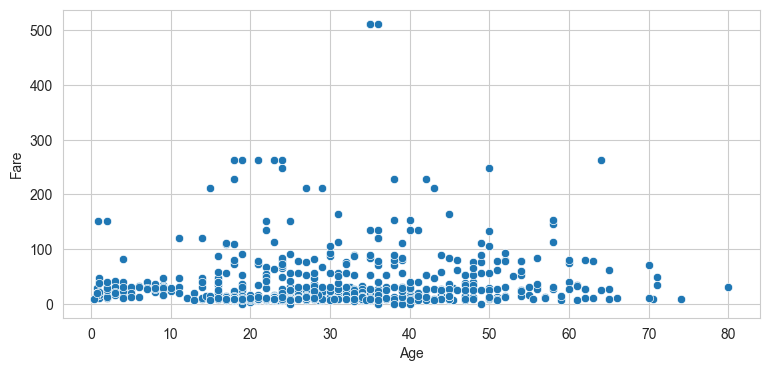

In [7]:
plt.figure(figsize=(9,4))
sns.scatterplot(x = df["age"], y=df["fare"])
plt.xlabel("Age")
plt.ylabel("Fare")
plt.show()

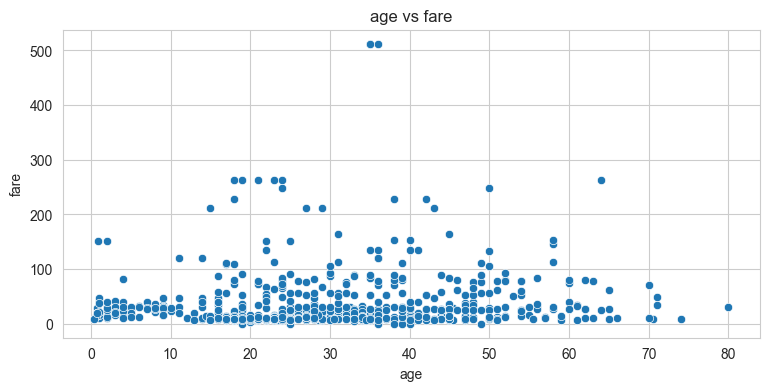

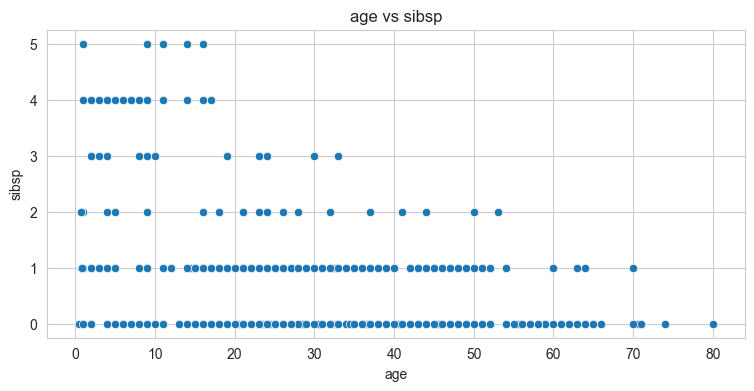

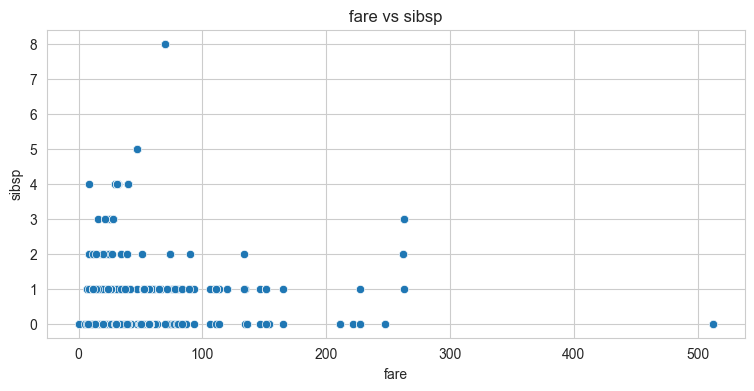

In [8]:
num_pairs = [
    ("age", "fare"),
    ("age", "sibsp"),
    ("fare", "sibsp")
]

for x, y in num_pairs:
    plt.figure(figsize=(9, 4))
    sns.scatterplot(data=df, x=x, y=y)
    plt.title(f"{x} vs {y}")
    plt.xlabel(x)
    plt.ylabel(y)
    
    plt.show()

**Correlation Matrix**

In [13]:
print("Correlation Matrix")
corr = df_nums.corr(numeric_only = True)

Correlation Matrix


In [10]:
df_nums

,survived,pclass,age,sibsp,parch,fare,survived_label
0,0,3,22.0,1,0,7.2500,No
1,1,1,38.0,1,0,71.2833,Yes
2,1,3,26.0,0,0,7.9250,Yes
3,1,1,35.0,1,0,53.1000,Yes
4,0,3,35.0,0,0,8.0500,No
...,...,...,...,...,...,...,...
885,0,3,39.0,0,5,29.1250,No
886,0,2,27.0,0,0,13.0000,No
887,1,1,19.0,0,0,30.0000,Yes
889,1,1,26.0,0,0,30.0000,Yes


In [15]:
print("Pearson correlation with fare")

for _ in num_cols:
    if _ != "fare":
        r, p = pearsonr(df_nums[_], df_nums["fare"])
        print(f"{_} vs fare: r: {r:.3f}: p: {p:.3f}")

Pearson correlation with fare
survived vs fare: r: 0.268: p: 0.000
pclass vs fare: r: -0.554: p: 0.000
age vs fare: r: 0.096: p: 0.010
sibsp vs fare: r: 0.138: p: 0.000
parch vs fare: r: 0.205: p: 0.000


**Numerical vs Category**

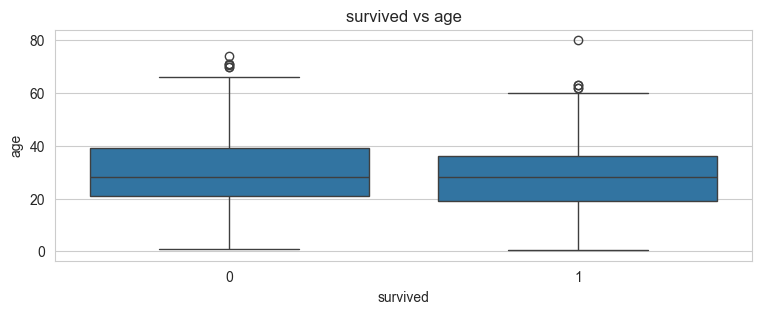

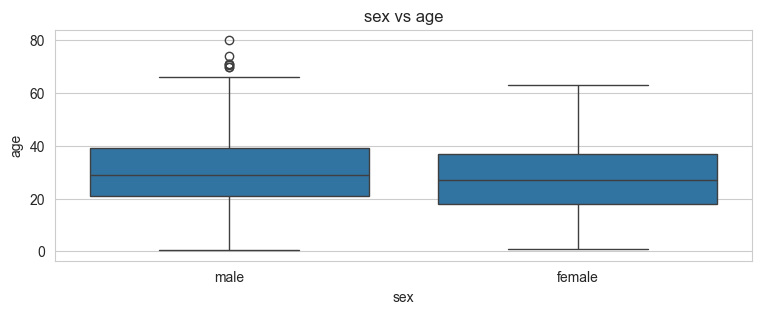

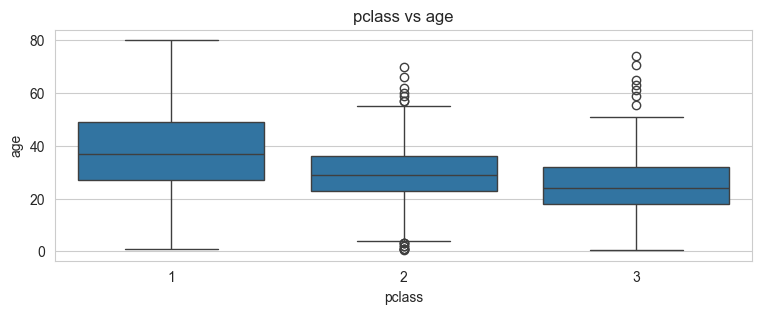

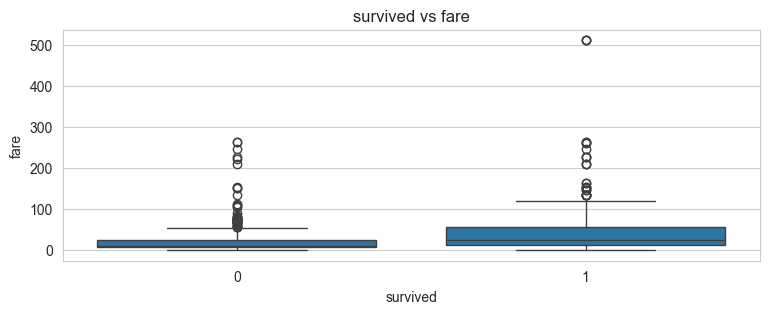

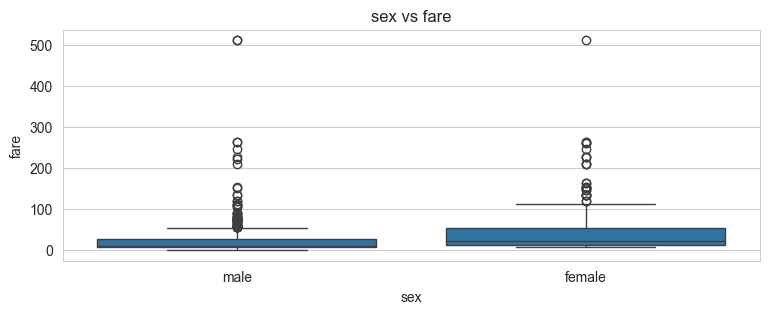

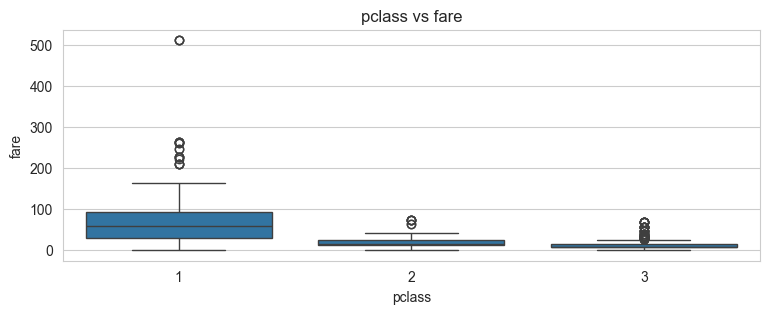

In [22]:
num_for_box = ["age", "fare"]
cat_for_box = ["survived", "sex", "pclass"]

for n in num_for_box:
    for c in cat_for_box:
        plt.figure(figsize=(9,3))
        sns.boxplot(x = df[c], y = df[n])
        plt.title(f"{c} vs {n}")
        plt.xlabel(c)
        plt.ylabel(n)
        plt.show()

**Grouped Statistics**

In [23]:
df_nums

,survived,pclass,age,sibsp,parch,fare,survived_label
0,0,3,22.0,1,0,7.2500,No
1,1,1,38.0,1,0,71.2833,Yes
2,1,3,26.0,0,0,7.9250,Yes
3,1,1,35.0,1,0,53.1000,Yes
4,0,3,35.0,0,0,8.0500,No
...,...,...,...,...,...,...,...
885,0,3,39.0,0,5,29.1250,No
886,0,2,27.0,0,0,13.0000,No
887,1,1,19.0,0,0,30.0000,Yes
889,1,1,26.0,0,0,30.0000,Yes


In [47]:
avg_survival = df_nums.groupby("survived_label")["age"].mean()

# or

df_nums.groupby("survived_label").mean()

,survived,pclass,age,sibsp,parch,fare
survived_label,,,,,,
No,0.0,2.485849,30.626179,0.525943,0.365566,22.965456
Yes,1.0,1.872414,28.343690,0.493103,0.527586,51.843205


**Crosstab Categorical Features**

In [55]:
# This function will show the frequency distribution of the combinations of values between these two columns, which can be helpful for analyzing relationships between categorical variables.

pd.crosstab(df_nums["pclass"], df_nums["survived_label"])

survived_label,No,Yes
pclass,,
1,64,122
2,90,83
3,270,85


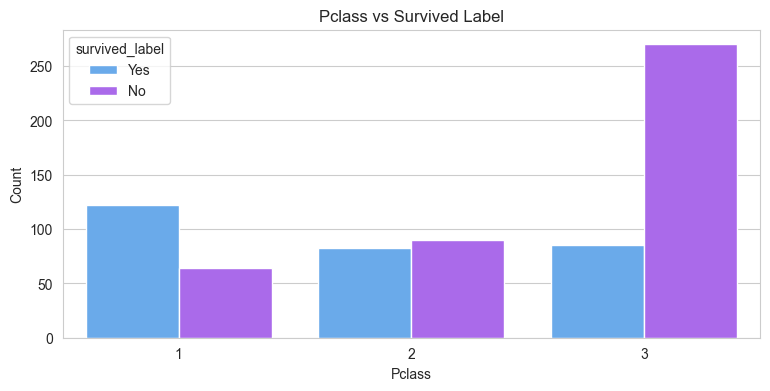

In [63]:
plt.figure(figsize=(9,4))
sns.countplot(x=df_nums["pclass"], hue=df_nums["survived_label"], palette="cool")
plt.title("Pclass vs Survived Label")
plt.xlabel("Pclass")
plt.ylabel("Count")
plt.show()